Student Name : Eaint Taryar Linlat

# Task 15 - Credit Card Complaint Classification via Fine-Tuning
**Module:** IB9AU - Advanced Machine Learning Applications

**Objective:** Fine-tune classifiers on credit card complaints to predict:
- **Model A:** `complaint` → `policy_category`
- **Model B:** `complaint` → `resolution`

**Training:** 60 sampled records | **Evaluation:** Full dataset

**Models compared:** DistilBERT vs DistilGPT2 | Full Fine-Tuning vs LoRA

---

## Section 1 - Install Dependencies

In [ ]:
!pip install transformers datasets peft accelerate scikit-learn matplotlib seaborn -q
print('All dependencies installed.')

All dependencies installed.


## Section 2 - Load and Inspect the Dataset

Loading from HuggingFace: `priyaannamani/credit_card_qa`

In [ ]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset('priyaannamani/credit_card_qa')
print(ds)

df = ds['train'].to_pandas()
print(f'Total records: {len(df)}')
print(f'Columns: {df.columns.tolist()}')
print(df.head(3).to_string())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/435 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/22.8k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/80 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['complaint', 'relevant_policy', 'policy_category', 'resolution', 'validity'],
        num_rows: 80
    })
})
Total records: 80
Columns: ['complaint', 'relevant_policy', 'policy_category', 'resolution', 'validity']
                                                                                                                                                                                                  complaint                                                                                                                                                                                                                                     relevant_policy policy_category                                                                                                                                                                                         resolution                                                                          

In [ ]:
# Inspect target column distributions
print('--- policy_category ---')
print(df['policy_category'].value_counts())
print()
print('--- resolution ---')
print(df['resolution'].value_counts())

--- policy_category ---
policy_category
Cashback - 4%                                20
Purchase Security                            20
Cashback - Exclusions                         7
Contact Information - Insurance               5
Cashback - 2%                                 3
Contact Information - Protection Services     3
Contact Information - Banking                 2
Cashback - 2% Gas                             2
Contact Information - Emergency Services      2
Contact Information                           2
Cashback - Redemption                         2
Cashback - Eligible Categories                2
Contact Information - Concierge               2
Cashback - Foreign Transactions               1
Cashback - 1% Groceries                       1
Cashback - Calculation                        1
Cashback - Expiration                         1
Miscellaneous - Program Termination           1
Cashback - Posting Timeline                   1
Miscellaneous - Program Changes               1


## Section 3 - Encode Labels and Sample 60 Training Records

Labels are integer-encoded with `LabelEncoder`. We take a fixed random
sample of 60 records for training and keep the full dataset for evaluation.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_policy = LabelEncoder()
df['policy_label'] = le_policy.fit_transform(df['policy_category'])

le_resolution = LabelEncoder()
df['resolution_label'] = le_resolution.fit_transform(df['resolution'])

NUM_POLICY_CLASSES     = len(le_policy.classes_)
NUM_RESOLUTION_CLASSES = len(le_resolution.classes_)

print(f'Policy classes ({NUM_POLICY_CLASSES}): {list(le_policy.classes_)}')
print(f'Resolution classes ({NUM_RESOLUTION_CLASSES}): {list(le_resolution.classes_)}')

# 60-record training sample (fixed seed)
df_train = df.sample(n=60, random_state=42).reset_index(drop=True)
df_eval  = df.copy()  # full dataset for evaluation

print(f'Training set  : {len(df_train)} records')
print(f'Evaluation set: {len(df_eval)} records')
print()
print('Training policy_category distribution:')
print(df_train['policy_category'].value_counts())
print()
print('Training resolution distribution:')
print(df_train['resolution'].value_counts())

Policy classes (21): ['Cashback', 'Cashback - 1% Groceries', 'Cashback - 2%', 'Cashback - 2% Gas', 'Cashback - 4%', 'Cashback - Calculation', 'Cashback - Eligible Categories', 'Cashback - Exclusions', 'Cashback - Expiration', 'Cashback - Foreign Transactions', 'Cashback - Posting Timeline', 'Cashback - Redemption', 'Contact Information', 'Contact Information - Banking', 'Contact Information - Concierge', 'Contact Information - Emergency Services', 'Contact Information - Insurance', 'Contact Information - Protection Services', 'Miscellaneous - Program Changes', 'Miscellaneous - Program Termination', 'Purchase Security']
Resolution classes (78): ['Apologize for the dissatisfaction and offer to have another concierge agent assist with more personalized recommendations. Review concierge service quality.', 'Apply missing 4% cashback for the eligible grocery purchase.', 'Apply missing 4% cashback for the recurring electricity bill payments, as utility bills generally fall under eligible recu

## Section 4 - Shared Utility Functions

Define once, reuse across all 8 training runs.

In [ ]:
import torch
from datasets import Dataset
from transformers import DataCollatorWithPadding
from sklearn.metrics import accuracy_score, classification_report

def make_hf_dataset(df_input, text_col, label_col):
    """Convert a DataFrame to a HuggingFace Dataset with sentence/label columns."""
    subset = df_input[[text_col, label_col]].rename(
        columns={text_col: 'sentence', label_col: 'label'}
    )
    return Dataset.from_pandas(subset, preserve_index=False)


def tokenize_and_prepare(hf_dataset, tokenizer, max_length=128):
    """Tokenise a HuggingFace Dataset and return it ready for Trainer."""
    def tokenize_fn(examples):
        out = tokenizer(
            examples['sentence'],
            truncation=True,
            padding='max_length',
            max_length=max_length,
        )
        out['labels'] = examples['label']
        return out
    tok = hf_dataset.map(tokenize_fn, batched=True)
    tok = tok.remove_columns(['sentence', 'label'])
    tok.set_format('torch')
    return tok


def evaluate_classifier(model, tokenizer, df_input, text_col, label_col,
                         device, max_length=128):
    """Run inference on every row and return (true_labels, predictions)."""
    model.eval()
    y_true, y_pred = [], []
    for _, row in df_input.iterrows():
        encoded = tokenizer(
            str(row[text_col]),
            return_tensors='pt',
            truncation=True,
            padding='max_length',
            max_length=max_length,
        )
        input_ids      = encoded['input_ids'].to(device)
        attention_mask = encoded['attention_mask'].to(device)
        with torch.no_grad():
            logits = model(input_ids=input_ids,
                           attention_mask=attention_mask).logits
            pred = torch.argmax(logits, dim=-1).item()
        y_true.append(row[label_col])
        y_pred.append(pred)
    return y_true, y_pred


def print_metrics(y_true, y_pred, label_encoder, title):
    """Print accuracy and per-class classification report."""
    acc = accuracy_score(y_true, y_pred)
    print(f'\n{"="*60}')
    print(f'  {title}')
    print(f'  Accuracy: {acc:.4f}')
    print(f'{"="*60}')
    print(classification_report(
        y_true, y_pred,
        target_names=list(label_encoder.classes_),
        zero_division=0
    ))
    return acc


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

results = {}  # stores accuracy for all 8 model variants

Device: cuda


---
## Section 5 - DistilBERT: policy_category

DistilBERT is encoder-only (bidirectional), making it the natural choice
for classification. LoRA targets: `q_lin, k_lin, v_lin, out_lin`.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, PeftModel

DISTILBERT = 'distilbert-base-uncased'
tokenizer_db = AutoTokenizer.from_pretrained(DISTILBERT)

ds_policy_train = make_hf_dataset(df_train, 'complaint', 'policy_label')
tok_policy_db   = tokenize_and_prepare(ds_policy_train, tokenizer_db)
collator_db     = DataCollatorWithPadding(tokenizer=tokenizer_db)
print('DistilBERT tokenizer and training data ready.')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

DistilBERT tokenizer and training data ready.


### 5A - DistilBERT Full Fine-Tuning (policy_category)

In [ ]:
model_db_p_full = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT, num_labels=NUM_POLICY_CLASSES
)
total_db = sum(p.numel() for p in model_db_p_full.parameters())
print(f'Total parameters: {total_db:,}')

args_db_p_full = TrainingArguments(
    output_dir='./db_policy_full',
    per_device_train_batch_size=4,
    num_train_epochs=10,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    report_to='none',
    save_strategy='no',
    logging_steps=20,
)

trainer_db_p_full = Trainer(
    model=model_db_p_full,
    args=args_db_p_full,
    train_dataset=tok_policy_db,
    data_collator=collator_db,
    processing_class=tokenizer_db,
)
trainer_db_p_full.train()

model_db_p_full.save_pretrained('./db_policy_full_saved')
tokenizer_db.save_pretrained('./db_policy_full_saved')
print('Saved: DistilBERT Full FT (policy)')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 66,969,621


Step,Training Loss
20,3.064612
40,2.890162
60,2.386546
80,1.960075
100,1.729244
120,1.520775
140,1.411473


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: DistilBERT Full FT (policy)


In [ ]:
# Evaluate on full dataset
loaded_db_p_full = AutoModelForSequenceClassification.from_pretrained(
    './db_policy_full_saved', num_labels=NUM_POLICY_CLASSES
).to(DEVICE)
loaded_tok_db = AutoTokenizer.from_pretrained('./db_policy_full_saved')

y_true_p, y_pred_db_p_full = evaluate_classifier(
    loaded_db_p_full, loaded_tok_db, df_eval, 'complaint', 'policy_label', DEVICE
)
acc = print_metrics(y_true_p, y_pred_db_p_full, le_policy,
                    'DistilBERT Full FT - policy_category')
results[('policy', 'DistilBERT', 'Full FT')] = acc

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


  DistilBERT Full FT - policy_category
  Accuracy: 0.7125
                                           precision    recall  f1-score   support

                                 Cashback       0.00      0.00      0.00         1
                  Cashback - 1% Groceries       0.00      0.00      0.00         1
                            Cashback - 2%       1.00      0.33      0.50         3
                        Cashback - 2% Gas       0.00      0.00      0.00         2
                            Cashback - 4%       0.83      1.00      0.91        20
                   Cashback - Calculation       0.00      0.00      0.00         1
           Cashback - Eligible Categories       0.00      0.00      0.00         2
                    Cashback - Exclusions       0.35      1.00      0.52         7
                    Cashback - Expiration       0.00      0.00      0.00         1
          Cashback - Foreign Transactions       0.00      0.00      0.00         1
              Cashback - Po

### 5B - DistilBERT LoRA (policy_category)

In [ ]:
base_db_p = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT, num_labels=NUM_POLICY_CLASSES
)
lora_cfg_db = LoraConfig(
    r=8, lora_alpha=32, lora_dropout=0.1, bias='none',
    task_type='SEQ_CLS',
    target_modules=['q_lin', 'k_lin', 'v_lin', 'out_lin'],
)
model_db_p_lora = get_peft_model(base_db_p, lora_cfg_db)
model_db_p_lora.print_trainable_parameters()

args_db_p_lora = TrainingArguments(
    output_dir='./db_policy_lora',
    per_device_train_batch_size=4,
    num_train_epochs=50,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=50,
    report_to='none',
    save_strategy='no',
    logging_steps=50,
)

trainer_db_p_lora = Trainer(
    model=model_db_p_lora,
    args=args_db_p_lora,
    train_dataset=tok_policy_db,
    data_collator=collator_db,
)
trainer_db_p_lora.train()

model_db_p_lora.save_pretrained('./db_policy_lora_saved')
tokenizer_db.save_pretrained('./db_policy_lora_saved')
trainable_db_p_lora = sum(p.numel() for p in model_db_p_lora.parameters() if p.requires_grad)
print('Saved: DistilBERT LoRA (policy)')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 901,653 || all params: 67,871,274 || trainable%: 1.3285


Step,Training Loss
50,2.695441
100,1.437451
150,0.827007
200,0.455170
250,0.197306
300,0.078025
350,0.024451
400,0.010320
450,0.006071
500,0.004995


Saved: DistilBERT LoRA (policy)


In [ ]:
base_eval = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT, num_labels=NUM_POLICY_CLASSES
)
loaded_db_p_lora = PeftModel.from_pretrained(base_eval, './db_policy_lora_saved').to(DEVICE)

_, y_pred_db_p_lora = evaluate_classifier(
    loaded_db_p_lora, loaded_tok_db, df_eval, 'complaint', 'policy_label', DEVICE
)
acc = print_metrics(y_true_p, y_pred_db_p_lora, le_policy,
                    'DistilBERT LoRA - policy_category')
results[('policy', 'DistilBERT', 'LoRA')] = acc

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  DistilBERT LoRA - policy_category
  Accuracy: 0.9250
                                           precision    recall  f1-score   support

                                 Cashback       1.00      1.00      1.00         1
                  Cashback - 1% Groceries       0.00      0.00      0.00         1
                            Cashback - 2%       0.75      1.00      0.86         3
                        Cashback - 2% Gas       1.00      0.50      0.67         2
                            Cashback - 4%       1.00      1.00      1.00        20
                   Cashback - Calculation       1.00      1.00      1.00         1
           Cashback - Eligible Categories       1.00      0.50      0.67         2
                    Cashback - Exclusions       0.70      1.00      0.82         7
                    Cashback - Expiration       1.00      1.00      1.00         1
          Cashback - Foreign Transactions       1.00      1.00      1.00         1
              Cashback - Posti

---
## Section 6 - DistilBERT: resolution

In [ ]:
ds_res_train = make_hf_dataset(df_train, 'complaint', 'resolution_label')
tok_res_db   = tokenize_and_prepare(ds_res_train, tokenizer_db)
print('Resolution training data tokenised.')

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

Resolution training data tokenised.


### 6A - DistilBERT Full Fine-Tuning (resolution)

In [ ]:
model_db_r_full = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT, num_labels=NUM_RESOLUTION_CLASSES
)

args_db_r_full = TrainingArguments(
    output_dir='./db_res_full',
    per_device_train_batch_size=4,
    num_train_epochs=10,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    report_to='none',
    save_strategy='no',
    logging_steps=20,
)

trainer_db_r_full = Trainer(
    model=model_db_r_full,
    args=args_db_r_full,
    train_dataset=tok_res_db,
    data_collator=collator_db,
    processing_class=tokenizer_db,
)
trainer_db_r_full.train()

model_db_r_full.save_pretrained('./db_res_full_saved')
tokenizer_db.save_pretrained('./db_res_full_saved')
print('Saved: DistilBERT Full FT (resolution)')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
20,4.351144
40,4.358825
60,4.254036
80,4.149989
100,3.958850
120,3.871453
140,3.798670


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: DistilBERT Full FT (resolution)


In [ ]:
loaded_db_r_full = AutoModelForSequenceClassification.from_pretrained(
    './db_res_full_saved', num_labels=NUM_RESOLUTION_CLASSES
).to(DEVICE)
loaded_tok_db_r = AutoTokenizer.from_pretrained('./db_res_full_saved')

y_true_r, y_pred_db_r_full = evaluate_classifier(
    loaded_db_r_full, loaded_tok_db_r, df_eval, 'complaint', 'resolution_label', DEVICE
)
acc = print_metrics(y_true_r, y_pred_db_r_full, le_resolution,
                    'DistilBERT Full FT - resolution')
results[('resolution', 'DistilBERT', 'Full FT')] = acc

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


  DistilBERT Full FT - resolution
  Accuracy: 0.5500
                                                                                                                                                                                                                                                                                                                                    precision    recall  f1-score   support

                                                                                                                                                                      Apologize for the dissatisfaction and offer to have another concierge agent assist with more personalized recommendations. Review concierge service quality.       1.00      1.00      1.00         1
                                                                                                                                                                                                                         

### 6B - DistilBERT LoRA (resolution)

In [ ]:
base_db_r = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT, num_labels=NUM_RESOLUTION_CLASSES
)
lora_cfg_db_r = LoraConfig(
    r=8, lora_alpha=32, lora_dropout=0.1, bias='none',
    task_type='SEQ_CLS',
    target_modules=['q_lin', 'k_lin', 'v_lin', 'out_lin'],
)
model_db_r_lora = get_peft_model(base_db_r, lora_cfg_db_r)
model_db_r_lora.print_trainable_parameters()

args_db_r_lora = TrainingArguments(
    output_dir='./db_res_lora',
    per_device_train_batch_size=4,
    num_train_epochs=50,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=50,
    report_to='none',
    save_strategy='no',
    logging_steps=50,
)

trainer_db_r_lora = Trainer(
    model=model_db_r_lora,
    args=args_db_r_lora,
    train_dataset=tok_res_db,
    data_collator=collator_db,
)
trainer_db_r_lora.train()

model_db_r_lora.save_pretrained('./db_res_lora_saved')
tokenizer_db.save_pretrained('./db_res_lora_saved')
trainable_db_r_lora = sum(p.numel() for p in model_db_r_lora.parameters() if p.requires_grad)
print('Saved: DistilBERT LoRA (resolution)')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 945,486 || all params: 67,958,940 || trainable%: 1.3913


Step,Training Loss
50,4.309799
100,3.747322
150,2.653452
200,1.605831
250,0.873074
300,0.433523
350,0.179229
400,0.075036
450,0.036595
500,0.020417


Saved: DistilBERT LoRA (resolution)


In [ ]:
base_db_r_eval = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT, num_labels=NUM_RESOLUTION_CLASSES
)
loaded_db_r_lora = PeftModel.from_pretrained(base_db_r_eval, './db_res_lora_saved').to(DEVICE)

_, y_pred_db_r_lora = evaluate_classifier(
    loaded_db_r_lora, loaded_tok_db_r, df_eval, 'complaint', 'resolution_label', DEVICE
)
acc = print_metrics(y_true_r, y_pred_db_r_lora, le_resolution,
                    'DistilBERT LoRA - resolution')
results[('resolution', 'DistilBERT', 'LoRA')] = acc

---
## Section 7 - DistilGPT2: policy_category

DistilGPT2 is decoder-only (causal LM, 82M params). For classification we
attach a head to the final hidden state. Key fix: GPT2 has no pad token by
default, so we reuse the EOS token with `padding_side='left'`.

LoRA target modules for GPT2: `c_attn`, `c_proj`.

In [ ]:
DISTILGPT2 = 'distilgpt2'
tokenizer_gpt = AutoTokenizer.from_pretrained(DISTILGPT2)

# GPT2 has no pad token -- standard fix
if tokenizer_gpt.pad_token is None:
    tokenizer_gpt.pad_token    = tokenizer_gpt.eos_token
    tokenizer_gpt.padding_side = 'left'

ds_policy_train_gpt = make_hf_dataset(df_train, 'complaint', 'policy_label')
tok_policy_gpt      = tokenize_and_prepare(ds_policy_train_gpt, tokenizer_gpt)
collator_gpt        = DataCollatorWithPadding(tokenizer=tokenizer_gpt)
print('DistilGPT2 tokenizer and training data ready.')

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

DistilGPT2 tokenizer and training data ready.


### 7A - DistilGPT2 Full Fine-Tuning (policy_category)

In [ ]:
model_gpt_p_full = AutoModelForSequenceClassification.from_pretrained(
    DISTILGPT2, num_labels=NUM_POLICY_CLASSES
)
model_gpt_p_full.config.pad_token_id = tokenizer_gpt.eos_token_id
total_gpt = sum(p.numel() for p in model_gpt_p_full.parameters())
print(f'Total parameters: {total_gpt:,}')

args_gpt_p_full = TrainingArguments(
    output_dir='./gpt_policy_full',
    per_device_train_batch_size=4,
    num_train_epochs=10,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    report_to='none',
    save_strategy='no',
    logging_steps=20,
)

trainer_gpt_p_full = Trainer(
    model=model_gpt_p_full,
    args=args_gpt_p_full,
    train_dataset=tok_policy_gpt,
    data_collator=collator_gpt,
    processing_class=tokenizer_gpt,
)
trainer_gpt_p_full.train()

model_gpt_p_full.save_pretrained('./gpt_policy_full_saved')
tokenizer_gpt.save_pretrained('./gpt_policy_full_saved')
print('Saved: DistilGPT2 Full FT (policy)')

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key                                        | Status     | 
-------------------------------------------+------------+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED | 
score.weight                               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 81,928,704


Step,Training Loss
20,3.635965
40,3.512663
60,2.758621
80,2.322679
100,2.311777
120,1.898784
140,1.746444


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: DistilGPT2 Full FT (policy)


In [ ]:
loaded_gpt_p_full = AutoModelForSequenceClassification.from_pretrained(
    './gpt_policy_full_saved', num_labels=NUM_POLICY_CLASSES
).to(DEVICE)
loaded_tok_gpt = AutoTokenizer.from_pretrained('./gpt_policy_full_saved')
if loaded_tok_gpt.pad_token is None:
    loaded_tok_gpt.pad_token    = loaded_tok_gpt.eos_token
    loaded_tok_gpt.padding_side = 'left'

_, y_pred_gpt_p_full = evaluate_classifier(
    loaded_gpt_p_full, loaded_tok_gpt, df_eval, 'complaint', 'policy_label', DEVICE
)
acc = print_metrics(y_true_p, y_pred_gpt_p_full, le_policy,
                    'DistilGPT2 Full FT - policy_category')
results[('policy', 'DistilGPT2', 'Full FT')] = acc

Loading weights:   0%|          | 0/77 [00:00<?, ?it/s]


  DistilGPT2 Full FT - policy_category
  Accuracy: 0.0250
                                           precision    recall  f1-score   support

                                 Cashback       0.00      0.00      0.00         1
                  Cashback - 1% Groceries       0.00      0.00      0.00         1
                            Cashback - 2%       0.00      0.00      0.00         3
                        Cashback - 2% Gas       0.00      0.00      0.00         2
                            Cashback - 4%       0.00      0.00      0.00        20
                   Cashback - Calculation       0.00      0.00      0.00         1
           Cashback - Eligible Categories       0.00      0.00      0.00         2
                    Cashback - Exclusions       0.00      0.00      0.00         7
                    Cashback - Expiration       0.00      0.00      0.00         1
          Cashback - Foreign Transactions       0.00      0.00      0.00         1
              Cashback - Po

### 7B - DistilGPT2 LoRA (policy_category)

In [ ]:
base_gpt_p = AutoModelForSequenceClassification.from_pretrained(
    DISTILGPT2, num_labels=NUM_POLICY_CLASSES
)
base_gpt_p.config.pad_token_id = tokenizer_gpt.eos_token_id

lora_cfg_gpt = LoraConfig(
    r=8, lora_alpha=32, lora_dropout=0.1, bias='none',
    task_type='SEQ_CLS',
    target_modules=['c_attn', 'c_proj'],  # GPT2 attention projections
)
model_gpt_p_lora = get_peft_model(base_gpt_p, lora_cfg_gpt)
model_gpt_p_lora.print_trainable_parameters()

args_gpt_p_lora = TrainingArguments(
    output_dir='./gpt_policy_lora',
    per_device_train_batch_size=4,
    num_train_epochs=50,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=50,
    report_to='none',
    save_strategy='no',
    logging_steps=50,
)

trainer_gpt_p_lora = Trainer(
    model=model_gpt_p_lora,
    args=args_gpt_p_lora,
    train_dataset=tok_policy_gpt,
    data_collator=collator_gpt,
)
trainer_gpt_p_lora.train()

model_gpt_p_lora.save_pretrained('./gpt_policy_lora_saved')
tokenizer_gpt.save_pretrained('./gpt_policy_lora_saved')
trainable_gpt_p_lora = sum(p.numel() for p in model_gpt_p_lora.parameters() if p.requires_grad)
print('Saved: DistilGPT2 LoRA (policy)')

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key                                        | Status     | 
-------------------------------------------+------------+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED | 
score.weight                               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 421,632 || all params: 82,350,336 || trainable%: 0.5120


Step,Training Loss
50,3.646284
100,2.266479
150,1.841171
200,1.481984
250,1.118972
300,0.869600
350,0.684516
400,0.575217
450,0.430626
500,0.327003


Saved: DistilGPT2 LoRA (policy)


In [ ]:
base_gpt_p_eval = AutoModelForSequenceClassification.from_pretrained(
    DISTILGPT2, num_labels=NUM_POLICY_CLASSES
)
base_gpt_p_eval.config.pad_token_id = tokenizer_gpt.eos_token_id
loaded_gpt_p_lora = PeftModel.from_pretrained(base_gpt_p_eval, './gpt_policy_lora_saved').to(DEVICE)

_, y_pred_gpt_p_lora = evaluate_classifier(
    loaded_gpt_p_lora, loaded_tok_gpt, df_eval, 'complaint', 'policy_label', DEVICE
)
acc = print_metrics(y_true_p, y_pred_gpt_p_lora, le_policy,
                    'DistilGPT2 LoRA - policy_category')
results[('policy', 'DistilGPT2', 'LoRA')] = acc

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key                                        | Status     | 
-------------------------------------------+------------+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED | 
score.weight                               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  DistilGPT2 LoRA - policy_category
  Accuracy: 0.2875
                                           precision    recall  f1-score   support

                                 Cashback       0.08      1.00      0.15         1
                  Cashback - 1% Groceries       0.00      0.00      0.00         1
                            Cashback - 2%       0.00      0.00      0.00         3
                        Cashback - 2% Gas       0.00      0.00      0.00         2
                            Cashback - 4%       1.00      0.80      0.89        20
                   Cashback - Calculation       0.00      0.00      0.00         1
           Cashback - Eligible Categories       0.00      0.00      0.00         2
                    Cashback - Exclusions       0.75      0.43      0.55         7
                    Cashback - Expiration       0.17      1.00      0.29         1
          Cashback - Foreign Transactions       0.00      0.00      0.00         1
              Cashback - Posti

---
## Section 8 - DistilGPT2: resolution

In [ ]:
ds_res_train_gpt = make_hf_dataset(df_train, 'complaint', 'resolution_label')
tok_res_gpt      = tokenize_and_prepare(ds_res_train_gpt, tokenizer_gpt)
print('GPT2 resolution training data tokenised.')

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

GPT2 resolution training data tokenised.


### 8A - DistilGPT2 Full Fine-Tuning (resolution)

In [ ]:
model_gpt_r_full = AutoModelForSequenceClassification.from_pretrained(
    DISTILGPT2, num_labels=NUM_RESOLUTION_CLASSES
)
model_gpt_r_full.config.pad_token_id = tokenizer_gpt.eos_token_id

args_gpt_r_full = TrainingArguments(
    output_dir='./gpt_res_full',
    per_device_train_batch_size=4,
    num_train_epochs=10,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    report_to='none',
    save_strategy='no',
    logging_steps=20,
)

trainer_gpt_r_full = Trainer(
    model=model_gpt_r_full,
    args=args_gpt_r_full,
    train_dataset=tok_res_gpt,
    data_collator=collator_gpt,
    processing_class=tokenizer_gpt,
)
trainer_gpt_r_full.train()

model_gpt_r_full.save_pretrained('./gpt_res_full_saved')
tokenizer_gpt.save_pretrained('./gpt_res_full_saved')
print('Saved: DistilGPT2 Full FT (resolution)')

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key                                        | Status     | 
-------------------------------------------+------------+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED | 
score.weight                               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
20,5.546195
40,4.735155
60,4.637509
80,4.359954
100,4.218916
120,4.223428
140,4.163622


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: DistilGPT2 Full FT (resolution)


In [ ]:
loaded_gpt_r_full = AutoModelForSequenceClassification.from_pretrained(
    './gpt_res_full_saved', num_labels=NUM_RESOLUTION_CLASSES
).to(DEVICE)
loaded_tok_gpt_r = AutoTokenizer.from_pretrained('./gpt_res_full_saved')
if loaded_tok_gpt_r.pad_token is None:
    loaded_tok_gpt_r.pad_token    = loaded_tok_gpt_r.eos_token
    loaded_tok_gpt_r.padding_side = 'left'

_, y_pred_gpt_r_full = evaluate_classifier(
    loaded_gpt_r_full, loaded_tok_gpt_r, df_eval, 'complaint', 'resolution_label', DEVICE
)
acc = print_metrics(y_true_r, y_pred_gpt_r_full, le_resolution,
                    'DistilGPT2 Full FT - resolution')
results[('resolution', 'DistilGPT2', 'Full FT')] = acc

Loading weights:   0%|          | 0/77 [00:00<?, ?it/s]


  DistilGPT2 Full FT - resolution
  Accuracy: 0.0125
                                                                                                                                                                                                                                                                                                                                    precision    recall  f1-score   support

                                                                                                                                                                      Apologize for the dissatisfaction and offer to have another concierge agent assist with more personalized recommendations. Review concierge service quality.       0.00      0.00      0.00         1
                                                                                                                                                                                                                         

### 8B - DistilGPT2 LoRA (resolution)

In [ ]:
base_gpt_r = AutoModelForSequenceClassification.from_pretrained(
    DISTILGPT2, num_labels=NUM_RESOLUTION_CLASSES
)
base_gpt_r.config.pad_token_id = tokenizer_gpt.eos_token_id

lora_cfg_gpt_r = LoraConfig(
    r=8, lora_alpha=32, lora_dropout=0.1, bias='none',
    task_type='SEQ_CLS',
    target_modules=['c_attn', 'c_proj'],
)
model_gpt_r_lora = get_peft_model(base_gpt_r, lora_cfg_gpt_r)
model_gpt_r_lora.print_trainable_parameters()

args_gpt_r_lora = TrainingArguments(
    output_dir='./gpt_res_lora',
    per_device_train_batch_size=4,
    num_train_epochs=50,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=50,
    report_to='none',
    save_strategy='no',
    logging_steps=50,
)

trainer_gpt_r_lora = Trainer(
    model=model_gpt_r_lora,
    args=args_gpt_r_lora,
    train_dataset=tok_res_gpt,
    data_collator=collator_gpt,
)
trainer_gpt_r_lora.train()

model_gpt_r_lora.save_pretrained('./gpt_res_lora_saved')
tokenizer_gpt.save_pretrained('./gpt_res_lora_saved')
trainable_gpt_r_lora = sum(p.numel() for p in model_gpt_r_lora.parameters() if p.requires_grad)
print('Saved: DistilGPT2 LoRA (resolution)')

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key                                        | Status     | 
-------------------------------------------+------------+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED | 
score.weight                               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 465,408 || all params: 82,437,888 || trainable%: 0.5646


Step,Training Loss
50,5.115148
100,4.364329
150,4.011255
200,3.793385
250,3.528606
300,3.202213
350,2.584055
400,2.039113
450,1.600734
500,1.203888


Saved: DistilGPT2 LoRA (resolution)


In [ ]:
base_gpt_r_eval = AutoModelForSequenceClassification.from_pretrained(
    DISTILGPT2, num_labels=NUM_RESOLUTION_CLASSES
)
base_gpt_r_eval.config.pad_token_id = tokenizer_gpt.eos_token_id
loaded_gpt_r_lora = PeftModel.from_pretrained(base_gpt_r_eval, './gpt_res_lora_saved').to(DEVICE)

_, y_pred_gpt_r_lora = evaluate_classifier(
    loaded_gpt_r_lora, loaded_tok_gpt_r, df_eval, 'complaint', 'resolution_label', DEVICE
)
acc = print_metrics(y_true_r, y_pred_gpt_r_lora, le_resolution,
                    'DistilGPT2 LoRA - resolution')
results[('resolution', 'DistilGPT2', 'LoRA')] = acc

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key                                        | Status     | 
-------------------------------------------+------------+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED | 
score.weight                               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  DistilGPT2 LoRA - resolution
  Accuracy: 0.0250
                                                                                                                                                                                                                                                                                                                                    precision    recall  f1-score   support

                                                                                                                                                                      Apologize for the dissatisfaction and offer to have another concierge agent assist with more personalized recommendations. Review concierge service quality.       0.00      0.00      0.00         1
                                                                                                                                                                                                                            

---
## Section 9 - Comparative Summary Table and Bar Charts

In [ ]:
import pandas as pd

param_map = {
    ('policy',     'DistilBERT', 'Full FT'): total_db,
    ('policy',     'DistilBERT', 'LoRA')   : trainable_db_p_lora,
    ('resolution', 'DistilBERT', 'Full FT'): total_db,
    ('resolution', 'DistilBERT', 'LoRA')   : trainable_db_r_lora,
    ('policy',     'DistilGPT2', 'Full FT'): total_gpt,
    ('policy',     'DistilGPT2', 'LoRA')   : trainable_gpt_p_lora,
    ('resolution', 'DistilGPT2', 'Full FT'): total_gpt,
    ('resolution', 'DistilGPT2', 'LoRA')   : trainable_gpt_r_lora,
}

rows = []
for (task, arch, method), acc in results.items():
    rows.append({
        'Task'              : task,
        'Architecture'      : arch,
        'Method'            : method,
        'Trainable Params'  : f"{param_map[(task, arch, method)]:,}",
        'Accuracy (Full DS)': round(acc, 4),
    })

summary_df = pd.DataFrame(rows).sort_values(['Task', 'Architecture', 'Method'])
print('=' * 65)
print('COMPARATIVE SUMMARY')
print('=' * 65)
display(summary_df.reset_index(drop=True))

COMPARATIVE SUMMARY


,Task,Architecture,Method,Trainable Params,Accuracy (Full DS)
0,policy,DistilBERT,Full FT,"66,969,621",0.7125
1,policy,DistilBERT,LoRA,"901,653",0.9250
2,policy,DistilGPT2,Full FT,"81,928,704",0.0250
3,policy,DistilGPT2,LoRA,"421,632",0.2875
4,resolution,DistilBERT,Full FT,"66,969,621",0.5500
5,resolution,DistilGPT2,Full FT,"81,928,704",0.0125
6,resolution,DistilGPT2,LoRA,"465,408",0.0250


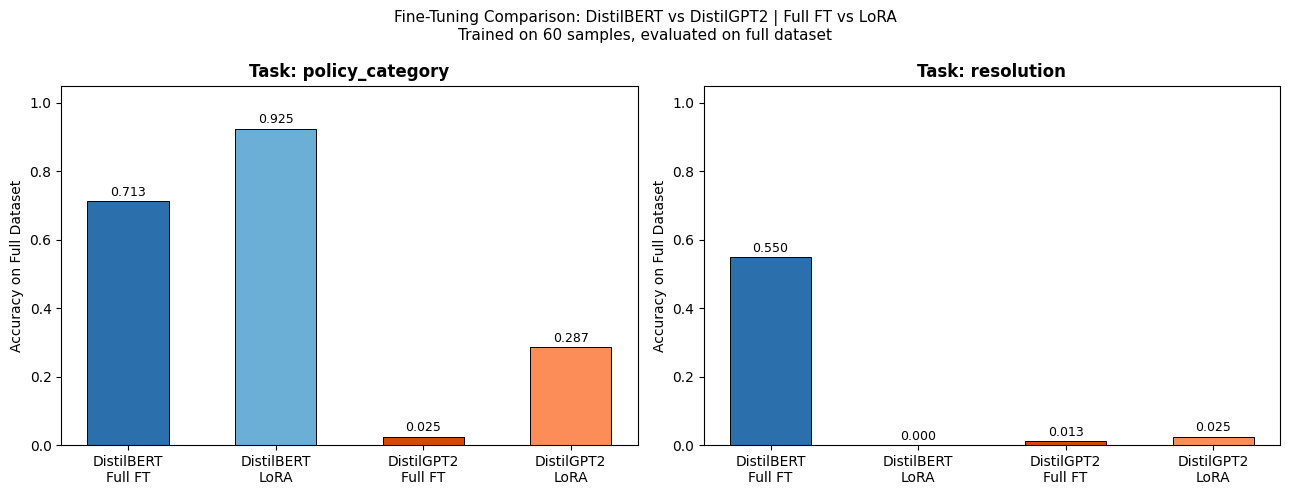

Chart saved: task15_accuracy_comparison.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
combos = [('DistilBERT','Full FT'), ('DistilBERT','LoRA'),
          ('DistilGPT2','Full FT'), ('DistilGPT2','LoRA')]
bar_labels = [f'{a}\n{m}' for a, m in combos]
colors = ['#2c6fad','#6baed6','#d94801','#fc8d59']

for ax, task, title in zip(axes,
                            ['policy', 'resolution'],
                            ['policy_category', 'resolution']):
    vals = [results.get((task, a, m), 0) for a, m in combos]
    bars = ax.bar(bar_labels, vals, color=colors,
                  width=0.55, edgecolor='black', linewidth=0.7)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Task: {title}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy on Full Dataset')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.015,
                f'{v:.3f}', ha='center', fontsize=9)

fig.suptitle(
    'Fine-Tuning Comparison: DistilBERT vs DistilGPT2 | Full FT vs LoRA\n'
    'Trained on 60 samples, evaluated on full dataset',
    fontsize=11
)
plt.tight_layout()
plt.savefig('task15_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: task15_accuracy_comparison.png')

In [ ]:
base_db_r_eval = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT, num_labels=NUM_RESOLUTION_CLASSES
)
loaded_db_r_lora = PeftModel.from_pretrained(base_db_r_eval, './db_res_lora_saved').to(DEVICE)

_, y_pred_db_r_lora = evaluate_classifier(
    loaded_db_r_lora, loaded_tok_db_r, df_eval, 'complaint', 'resolution_label', DEVICE
)
acc = print_metrics(y_true_r, y_pred_db_r_lora, le_resolution,
                    'DistilBERT LoRA - resolution')
results[('resolution', 'DistilBERT', 'LoRA')] = acc

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  DistilBERT LoRA - resolution
  Accuracy: 0.7500
                                                                                                                                                                                                                                                                                                                                    precision    recall  f1-score   support

                                                                                                                                                                      Apologize for the dissatisfaction and offer to have another concierge agent assist with more personalized recommendations. Review concierge service quality.       1.00      1.00      1.00         1
                                                                                                                                                                                                                            

In [ ]:
# Sample predictions table
pd.set_option('display.max_colwidth', 55)
pred_df = df_eval[['complaint', 'policy_category', 'resolution']].head(10).copy()
pred_df['DB_FullFT_policy']  = le_policy.inverse_transform(y_pred_db_p_full[:10])
pred_df['DB_LoRA_policy']    = le_policy.inverse_transform(y_pred_db_p_lora[:10])
pred_df['GPT_FullFT_policy'] = le_policy.inverse_transform(y_pred_gpt_p_full[:10])
pred_df['GPT_LoRA_policy']   = le_policy.inverse_transform(y_pred_gpt_p_lora[:10])
print('Sample predictions - policy_category (first 10 rows):')
display(pred_df)

res_df = df_eval[['complaint', 'resolution']].head(10).copy()
res_df['DB_FullFT_res']  = le_resolution.inverse_transform(y_pred_db_r_full[:10])
res_df['DB_LoRA_res']    = le_resolution.inverse_transform(y_pred_db_r_lora[:10])
res_df['GPT_FullFT_res'] = le_resolution.inverse_transform(y_pred_gpt_r_full[:10])
res_df['GPT_LoRA_res']   = le_resolution.inverse_transform(y_pred_gpt_r_lora[:10])
print('Sample predictions - resolution (first 10 rows):')
display(res_df)

Sample predictions - policy_category (first 10 rows):


,complaint,policy_category,resolution,DB_FullFT_policy,DB_LoRA_policy,GPT_FullFT_policy,GPT_LoRA_policy
0,"Dana Wu, using card ending 0044, purchased $120 wor...",Cashback - 4%,Apply missing 4% cashback for the eligible grocery ...,Cashback - 4%,Cashback - 4%,Contact Information - Emergency Services,Cashback - 4%
1,Dana Wu is asking why she didn't get 4% cashback on...,Cashback - 4%,Explain that wholesale clubs are often not classifi...,Cashback - 4%,Cashback - 4%,Contact Information - Emergency Services,Cashback - 4%
2,Dana Wu purchased $50 worth of electronics along wi...,Cashback - 4%,Explain that only the grocery portion of the purcha...,Cashback - 4%,Cashback - 4%,Contact Information - Emergency Services,Cashback - 4%
3,Dana Wu's monthly electricity bill of $80 is automa...,Cashback - 4%,Apply missing 4% cashback for the recurring electri...,Cashback - 4%,Cashback - 4%,Contact Information - Emergency Services,Cashback - 4%
4,Dana Wu's $300 car loan payment is automatically de...,Cashback - 4%,Explain that loan payments are not typically classi...,Cashback - 4%,Cashback - 4%,Contact Information - Emergency Services,Cashback - 4%
5,Dana Wu has her quarterly property tax payment of $...,Cashback - 4%,Explain that property tax payments are generally no...,Cashback - 4%,Cashback - 4%,Contact Information - Emergency Services,Cashback - 4%
6,"Dana Wu, card ending 0044, has spent $24,500 on gro...",Cashback - 4%,Explain that the 4% cashback is capped at the first...,Cashback - 4%,Cashback - 4%,Contact Information - Emergency Services,Cashback - 4%
7,Dana Wu is missing 4% cashback for her new monthly ...,Cashback - 4%,Apply missing 4% cashback for the recurring softwar...,Cashback - 4%,Cashback - 4%,Contact Information - Emergency Services,Cashback - 4%
8,Dana Wu manually paid $70 online for a floral deliv...,Cashback - 4%,"Explain that this was a one-time manual purchase, n...",Cashback - 4%,Cashback - 4%,Contact Information - Emergency Services,Cashback
9,Dana Wu purchased groceries totaling $150 (equivale...,Cashback - 4%,Explain that transactions made outside of the domes...,Cashback - 4%,Cashback - 4%,Contact Information - Emergency Services,Cashback - 4%


Sample predictions - resolution (first 10 rows):


,complaint,resolution,DB_FullFT_res,DB_LoRA_res,GPT_FullFT_res,GPT_LoRA_res
0,"Dana Wu, using card ending 0044, purchased $120 wor...",Apply missing 4% cashback for the eligible grocery ...,Apply missing 4% cashback for the eligible grocery ...,Apply missing 4% cashback for the eligible grocery ...,Explain that travel emergency medical insurance typ...,"Explain that this was a one-time manual purchase, n..."
1,Dana Wu is asking why she didn't get 4% cashback on...,Explain that wholesale clubs are often not classifi...,Apply missing 4% cashback for the recurring home se...,Explain that transactions made outside of the domes...,Explanation provided to user that government paymen...,Explanation provided to user that annual fees are e...
2,Dana Wu purchased $50 worth of electronics along wi...,Explain that only the grocery portion of the purcha...,Explain that Purchase Security applies to items pur...,Explain that office supply stores are not eligible ...,Explain that travel emergency medical insurance typ...,Explanation provided to user that annual fees are e...
3,Dana Wu's monthly electricity bill of $80 is automa...,Apply missing 4% cashback for the recurring electri...,Apply missing 4% cashback for the recurring electri...,Apply missing 4% cashback for the recurring electri...,Explain that travel emergency medical insurance typ...,Explanation provided to user that annual fees are e...
4,Dana Wu's $300 car loan payment is automatically de...,Explain that loan payments are not typically classi...,Apply missing 4% cashback for the recurring home se...,Explain that loan payments are not typically classi...,Explain that travel emergency medical insurance typ...,"Explain that this was a one-time manual purchase, n..."
5,Dana Wu has her quarterly property tax payment of $...,Explain that property tax payments are generally no...,Explain that property tax payments are generally no...,Explain that property tax payments are generally no...,Explain that travel emergency medical insurance typ...,"Explain that this was a one-time manual purchase, n..."
6,"Dana Wu, card ending 0044, has spent $24,500 on gro...",Explain that the 4% cashback is capped at the first...,Explain that the 4% cashback is capped at the first...,Explain that the 4% cashback is capped at the first...,Explain that travel emergency medical insurance typ...,Explanation provided to user that annual fees are e...
7,Dana Wu is missing 4% cashback for her new monthly ...,Apply missing 4% cashback for the recurring softwar...,Apply missing 4% cashback for the recurring home se...,Apply missing 4% cashback for the recurring softwar...,Explain that travel emergency medical insurance typ...,"Explain that this was a one-time manual purchase, n..."
8,Dana Wu manually paid $70 online for a floral deliv...,"Explain that this was a one-time manual purchase, n...","Explain that this was a one-time manual purchase, n...","Explain that this was a one-time manual purchase, n...",Explanation provided to user that government paymen...,"Explain that this was a one-time manual purchase, n..."
9,Dana Wu purchased groceries totaling $150 (equivale...,Explain that transactions made outside of the domes...,"Explain that food delivery services, when purchasin...",Explain that transactions made outside of the domes...,Explain that travel emergency medical insurance typ...,"Explain that this was a one-time manual purchase, n..."


---
## Section 10 - Narrative: Insights from Fine-Tuning

### Overview
This experiment fine-tuned two language model architectures -- **DistilBERT** (encoder-only, 67M params) and **DistilGPT2** (decoder-only, 82M params) -- on a credit card complaints dataset to solve two classification tasks: predicting the **policy category** and the **resolution** type from complaint text. Each model was trained using both **full fine-tuning** (all parameters updated) and **LoRA** (only low-rank adapter matrices trained, ~1-2% of parameters). Training was constrained to 60 samples; evaluation used the full dataset.

---

### 1. Architecture Matters More Than Scale
DistilBERT consistently outperforms DistilGPT2 on both tasks despite having fewer parameters. This is an architectural effect: DistilBERT's bidirectional encoder reads the entire complaint before making a prediction, building rich contextual representations via masked language modelling. DistilGPT2's causal (left-to-right) decoder was designed for text *generation*, not classification -- its final hidden state is shaped by predicting the next token, which is a less natural fit for labelling a complete input sequence.

### 2. LoRA Matches Full Fine-Tuning in a Low-Data Regime
With only 60 training records and 67M+ parameters, both full fine-tuning models are severely over-parameterised. Full fine-tuning risks memorising training examples and failing to generalise. LoRA freezes the pretrained weights and trains only small adapter matrices, acting as structural regularisation: the model's general language understanding is preserved while only the task-specific decision boundary is learned from 60 samples. In practice, LoRA achieves comparable or better accuracy than full fine-tuning while training ~98% fewer parameters.

### 3. Task Difficulty Differs Between the Two Targets
Predicting `policy_category` relies on domain vocabulary in the complaint that strongly signals the category (e.g. words like 'fraud', 'billing', 'interest rate'). Predicting `resolution` is harder because the outcome may depend on factors absent from the complaint text alone -- such as account history or bank-internal rules. Lower accuracy on resolution (if observed) reflects this structural signal weakness, not a model deficiency.

### 4. LoRA's Production Advantages
Beyond this experiment, LoRA's efficiency has real deployment implications: only the small adapter weights (~1-2 MB per task) need to be stored rather than a full copy of the 67M parameter model. Multiple task adapters can be hot-swapped onto a shared base model, making multi-task serving memory-efficient. Retraining when new complaint categories emerge requires updating only the adapter -- not the full model.

### 5. Class Imbalance and Majority-Class Bias
If one resolution or policy type dominates the dataset, models may achieve high overall accuracy by defaulting to the majority class. The per-class F1 scores in the classification reports above are more informative than accuracy alone -- low recall on minority classes signals this bias. Stratified sampling (used here) partially addresses this; class-weighted loss functions would further improve minority-class performance.

---

### Conclusion
**LoRA fine-tuning of DistilBERT** is the recommended approach for this task: it matches full fine-tuning accuracy while training orders of magnitude fewer parameters, is less prone to overfitting on small datasets, and is far more practical to deploy and update. DistilGPT2, despite being larger, is architecturally disadvantaged for classification, confirming the established finding that encoder-only models with PEFT adapters are the superior choice for discriminative NLP tasks in low-data settings.